In [71]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [72]:
df = pd.read_csv("training_with_augmentation/test_predictions.csv")
df.head()

,filename,predicted_label,true_label
0,Image_0001,0,0
1,Image_0002,4,7
2,Image_0003,5,5
3,Image_0004,1,1
4,Image_0005,4,4


In [73]:
class_names = [
    "Amphibia",
    "Animalia", 
    "Arachnida",
    "Aves",
    "Fungi",
    "Insecta",
    "Mammalia",
    "Mollusca",
    "Plantae",
    "Reptilia"
]

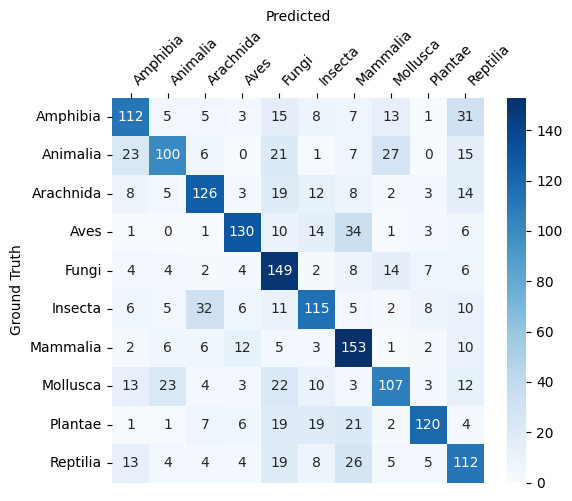

In [ ]:
# do a confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(df["true_label"], df["predicted_label"])

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")

plt.xticks(rotation=45, ha="left")
plt.yticks(rotation=0)

#plt.savefig("confusion_matrix.svg", format="svg", bbox_inches="tight")
plt.show()

In [75]:
#calculate the accuracy
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.61


In [76]:
#calculate the class accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)
class_accuracy

array([0.56 , 0.5  , 0.63 , 0.65 , 0.745, 0.575, 0.765, 0.535, 0.6  ,
       0.56 ])

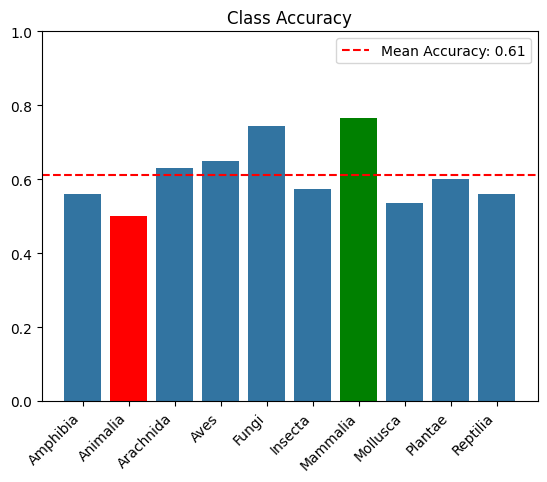

In [ ]:
sns.barplot(x=class_names, y=class_accuracy)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Class Accuracy")
#mark the best class
best_class = np.argmax(class_accuracy)
plt.bar(best_class, class_accuracy[best_class], color="green")
#line for mean accuracy
mean_accuracy = np.mean(class_accuracy)
plt.axhline(mean_accuracy, color="red", linestyle="--", label=f"Mean Accuracy: {mean_accuracy:.2f}")
#mark the worst class
worst_class = np.argmin(class_accuracy)
plt.bar(worst_class, class_accuracy[worst_class], color="red")
plt.legend()
#plt.savefig("class_accuracy.svg", format="svg", bbox_inches="tight")
plt.show()